In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("customers_raw.csv")
orders = pd.read_csv("orders_raw.csv")
order_details = pd.read_csv("order_details_raw.csv")
products = pd.read_csv("products_raw.csv")
shipping = pd.read_csv("shipping_raw.csv")

In [4]:
customers.shape

(12000, 8)

In [7]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer_ID       12000 non-null  str  
 1   Customer_Name     12000 non-null  str  
 2   Age               12000 non-null  int64
 3   Gender            11752 non-null  str  
 4   City              11524 non-null  str  
 5   State             11651 non-null  str  
 6   Region            11315 non-null  str  
 7   Customer_Segment  11652 non-null  str  
dtypes: int64(1), str(7)
memory usage: 1.4 MB


In [9]:
customers.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Region,Customer_Segment
0,CUST10000,Customer_0,56,Female,Kolkata,Delhi,South,consumer
1,CUST10001,Customer_1,69,Male,Ahmedabad,Delhi,East,NaN
2,CUST10002,Customer_2,46,Female,NaN,Rajasthan,West,Corporate
3,CUST10003,Customer_3,32,Female,Ahmedabad,Tamil Nadu,North,Corporate
4,CUST10004,Customer_4,60,Female,Mumbai,Gujarat,South,Small Business


In [20]:
customers.tail()

,Customer_ID,Customer_Name,Age,Gender,City,State,Region,Customer_Segment
11995,CUST21995,Customer_11995,69,Female,Ahmedabad,Karnataka,West,consumer
11996,CUST21996,Customer_11996,20,Female,Chennai,Karnataka,South,Corporate
11997,CUST21997,Customer_11997,66,Male,Hyderabad,West Bengal,South,NaN
11998,CUST21998,Customer_11998,61,FEMALE,Lucknow,Gujarat,South,Corporate
11999,CUST21999,Customer_11999,49,Male,Delhi,Gujarat,East,Consumer


In [10]:
customers.isnull().sum()

Customer_ID           0
Customer_Name         0
Age                   0
Gender              248
City                476
State               349
Region              685
Customer_Segment    348
dtype: int64

In [22]:

customers["Gender"] = customers["Gender"].fillna("Unknown")
customers["City"] = customers["City"].fillna("Unknown")
customers["State"] = customers["State"].fillna("Unknown")
customers["Region"] = customers["Region"].fillna("Unknown")
customers["Customer_Segment"] = customers["Customer_Segment"].fillna("Unknown")

In [23]:
customers.isnull().sum()

Customer_ID         0
Customer_Name       0
Age                 0
Gender              0
City                0
State               0
Region              0
Customer_Segment    0
dtype: int64

In [4]:
customers["Gender"].unique()

<ArrowStringArray>
['Female', 'Male', nan, 'Other']
Length: 4, dtype: str

In [3]:
customers["Gender"] = customers["Gender"].str.strip().str.capitalize()

In [5]:
customers.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Region,Customer_Segment
0,CUST10000,Customer_0,56,Female,Kolkata,Delhi,South,consumer
1,CUST10001,Customer_1,69,Male,Ahmedabad,Delhi,East,NaN
2,CUST10002,Customer_2,46,Female,NaN,Rajasthan,West,Corporate
3,CUST10003,Customer_3,32,Female,Ahmedabad,Tamil Nadu,North,Corporate
4,CUST10004,Customer_4,60,Female,Mumbai,Gujarat,South,Small Business


In [7]:
customers["State"].unique()

<ArrowStringArray>
[        'Delhi',     'Rajasthan',    'Tamil Nadu',       'Gujarat',
   'Maharashtra', 'Uttar Pradesh',     'Karnataka',     'Telangana',
   'West Bengal',             nan]
Length: 10, dtype: str

In [8]:
customers["Region"].unique()

<ArrowStringArray>
['South', 'East', 'West', 'North', ' north ', 'SOUTH', nan]
Length: 7, dtype: str

In [11]:
customers["Customer_Segment"].unique()

<ArrowStringArray>
['Consumer', nan, 'Corporate', 'Small Business']
Length: 4, dtype: str

In [10]:
customers['Customer_Segment'] = (
    customers['Customer_Segment']
    .str.strip()
    .str.title()
)

In [12]:
customers.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Region,Customer_Segment
0,CUST10000,Customer_0,56,Female,Kolkata,Delhi,South,Consumer
1,CUST10001,Customer_1,69,Male,Ahmedabad,Delhi,East,NaN
2,CUST10002,Customer_2,46,Female,NaN,Rajasthan,West,Corporate
3,CUST10003,Customer_3,32,Female,Ahmedabad,Tamil Nadu,North,Corporate
4,CUST10004,Customer_4,60,Female,Mumbai,Gujarat,South,Small Business


In [14]:
customers.describe()

,Age
count,12000.000000
mean,43.489250
std,14.908982
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


In [15]:
bins = [0, 18, 30, 45, 60, 100]
labels = ['Minor', 'Young Adult', 'Adult', 'Middle-Aged', 'Senior']

customers['Age_Category'] = pd.cut(customers['Age'], bins=bins, labels=labels, right=False)

In [20]:
customers.duplicated().sum()

np.int64(0)

In [16]:
customers.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Region,Customer_Segment,Age_Category
0,CUST10000,Customer_0,56,Female,Kolkata,Delhi,South,Consumer,Middle-Aged
1,CUST10001,Customer_1,69,Male,Ahmedabad,Delhi,East,NaN,Senior
2,CUST10002,Customer_2,46,Female,NaN,Rajasthan,West,Corporate,Middle-Aged
3,CUST10003,Customer_3,32,Female,Ahmedabad,Tamil Nadu,North,Corporate,Adult
4,CUST10004,Customer_4,60,Female,Mumbai,Gujarat,South,Small Business,Senior


In [17]:
orders.head()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
0,ORD100000,CUST10646,2025-12-30 00:00:00,Economy,Pending
1,ORD100001,CUST10326,2024-12-21 00:00:00,Same Day,Delivered
2,ORD100002,CUST18191,2025-04-19 00:00:00,Standard,Shipped
3,ORD100003,CUST20996,2024-09-12 00:00:00,Standard,Delivered
4,ORD100004,CUST21827,2025-06-23 00:00:00,Standard,Delivered


In [18]:
orders.tail()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
59995,ORD159995,CUST20136,2022-09-29 00:00:00,Standard,Delivered
59996,ORD159996,CUST18662,2025-07-14 00:00:00,Standard,Delivered
59997,ORD159997,CUST16466,2024-03-20 00:00:00,Express,Cancelled
59998,ORD159998,CUST19979,2024-04-09 00:00:00,Standard,Delivered
59999,ORD159999,CUST12216,2022-09-08 00:00:00,Standard,Delivered


In [21]:
orders.shape

(60000, 5)

In [22]:
orders.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Shipping_Mode',
       'Order_Status'],
      dtype='str')

In [28]:
orders.describe()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
count,60000,60000,60000,57067,60000
unique,60000,11921,1462,4,5
top,ORD100000,CUST13819,not_a_date,Standard,Delivered
freq,1,16,80,26526,41978


In [29]:
orders.duplicated().sum()

np.int64(0)

In [30]:
orders.head()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
0,ORD100000,CUST10646,2025-12-30 00:00:00,Economy,Pending
1,ORD100001,CUST10326,2024-12-21 00:00:00,Same Day,Delivered
2,ORD100002,CUST18191,2025-04-19 00:00:00,Standard,Shipped
3,ORD100003,CUST20996,2024-09-12 00:00:00,Standard,Delivered
4,ORD100004,CUST21827,2025-06-23 00:00:00,Standard,Delivered


In [31]:
orders['Order_Date'].head()

0    2025-12-30 00:00:00
1    2024-12-21 00:00:00
2    2025-04-19 00:00:00
3    2024-09-12 00:00:00
4    2025-06-23 00:00:00
Name: Order_Date, dtype: str

In [33]:
mask = pd.to_datetime(orders['Order_Date'], errors='coerce').isna()
orders[mask]

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
738,ORD100738,CUST10593,not_a_date,Express,Delivered
1454,ORD101454,CUST18249,not_a_date,Standard,Delivered
1968,ORD101968,CUST21240,not_a_date,Standard,Delivered
3037,ORD103037,CUST20613,not_a_date,Standard,Delivered
3371,ORD103371,CUST21775,not_a_date,Standard,Delivered
...,...,...,...,...,...
56250,ORD156250,CUST14646,not_a_date,Standard,Pending
56608,ORD156608,CUST17226,not_a_date,NaN,Delivered
57156,ORD157156,CUST18384,not_a_date,Economy,Delivered
57710,ORD157710,CUST18464,not_a_date,Economy,Delivered


In [41]:
orders.loc[mask, 'Order_Date'].value_counts()

Series([], Name: count, dtype: int64)

In [42]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'], errors='coerce').dt.date

In [43]:
# check impact first
print(f"Total rows: {len(orders)}, bad rows: {mask.sum()} ({mask.sum()/len(orders):.1%})")

# then drop if that % is small and acceptable
orders = orders.dropna(subset=['Order_Date'])

Total rows: 59920, bad rows: 80 (0.1%)


In [45]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'], errors='coerce').dt.date
orders = orders.dropna(subset=['Order_Date'])

In [46]:
orders['Order_Date'].isna().sum()  # should be 0
len(orders)  # should be 59840

59920

In [47]:
orders['Order_Date'].isna().sum()

np.int64(0)

In [48]:
len(orders)

59920

In [55]:
# --- Order_Date: clean date format ---
orders['Order_Date'] = pd.to_datetime(orders['Order_Date']).dt.date

# --- Gender: normalize casing/whitespace ---
customers['Gender'] = customers['Gender'].str.strip().str.capitalize()

# --- Customer_Segment: normalize casing/whitespace, handle missing ---
customers['Customer_Segment'] = customers['Customer_Segment'].str.strip().str.title()
customers['Customer_Segment'] = customers['Customer_Segment'].fillna('Unknown')

# --- Age_Category: bin numeric Age into groups ---
bins = [0, 18, 30, 45, 60, 100]
labels = ['<18', '18-29', '30-44', '45-59', '60+']  # or your preferred label style
customers['Age_Category'] = pd.cut(customers['Age'], bins=bins, labels=labels, right=False)

In [56]:
orders.head()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
0,ORD100000,CUST10646,2025-12-30,Economy,Pending
1,ORD100001,CUST10326,2024-12-21,Same Day,Delivered
2,ORD100002,CUST18191,2025-04-19,Standard,Shipped
3,ORD100003,CUST20996,2024-09-12,Standard,Delivered
4,ORD100004,CUST21827,2025-06-23,Standard,Delivered


In [58]:
orders.tail()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status
59995,ORD159995,CUST20136,2022-09-29,Standard,Delivered
59996,ORD159996,CUST18662,2025-07-14,Standard,Delivered
59997,ORD159997,CUST16466,2024-03-20,Express,Cancelled
59998,ORD159998,CUST19979,2024-04-09,Standard,Delivered
59999,ORD159999,CUST12216,2022-09-08,Standard,Delivered


In [65]:
orders["Order_Status"].unique()

<ArrowStringArray>
['Pending', 'Delivered', 'Shipped', 'Cancelled', 'Returned']
Length: 5, dtype: str

In [66]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

orders['Order_Year'] = orders['Order_Date'].dt.year
orders['Order_Month'] = orders['Order_Date'].dt.month
orders['Order_Day'] = orders['Order_Date'].dt.day

orders['Order_Date'] = orders['Order_Date'].dt.date

In [67]:
orders.head()

,Order_ID,Customer_ID,Order_Date,Shipping_Mode,Order_Status,Order_Year,Order_Month,Order_Day
0,ORD100000,CUST10646,2025-12-30,Economy,Pending,2025,12,30
1,ORD100001,CUST10326,2024-12-21,Same Day,Delivered,2024,12,21
2,ORD100002,CUST18191,2025-04-19,Standard,Shipped,2025,4,19
3,ORD100003,CUST20996,2024-09-12,Standard,Delivered,2024,9,12
4,ORD100004,CUST21827,2025-06-23,Standard,Delivered,2025,6,23


In [68]:
order_details.head()

,Order_ID,Product_ID,Quantity,Discount,Payment_Mode,Unit_Price,Sales,Cost,Profit
0,ORD100000,PROD1254,1,0.20,Debit Card,23821.98,19057.584,12551.900758,6505.683242
1,ORD100001,PROD1032,8,0.15,Credit Card,23135.52,157321.536,139567.394744,17754.141256
2,ORD100002,PROD1091,2,0.05,Cash on Delivery,27849.12,52913.328,40012.570436,12900.757564
3,ORD100003,PROD1260,1,0.00,Net Banking,81867.05,81867.050,58105.177546,23761.872454
4,ORD100004,PROD1249,1,0.10,UPI,67765.51,60988.959,44688.227193,16300.731807


In [69]:
order_details.tail()

,Order_ID,Product_ID,Quantity,Discount,Payment_Mode,Unit_Price,Sales,Cost,Profit
60495,ORD121342,PROD1370,1,0.05,UPI,1153.26,1095.597,934.452722,161.144278
60496,ORD102586,PROD1328,3,0.20,UPI,33159.15,79581.960,45970.472749,33611.487251
60497,ORD119717,PROD1298,3,0.10,UPI,80500.19,217350.513,121528.862853,95821.650147
60498,ORD100772,PROD1065,3,0.10,UPI,68682.47,185442.669,142066.642961,43376.026039
60499,ORD108638,PROD1332,2,0.40,UPI,77973.16,93567.792,53407.962162,40159.829838


In [70]:
order_details.shape

(60500, 9)

In [73]:
real_mismatches = order_details[order_details['Sales_Mismatch'] & order_details['Sales'].notna()].copy()
real_mismatches['Ratio'] = real_mismatches['Sales'] / real_mismatches['Expected_Sales']
print(real_mismatches['Ratio'].describe())
real_mismatches[['Order_ID', 'Sales', 'Expected_Sales', 'Ratio']]

count    61.000000
mean     10.520766
std       2.772533
min       5.087631
25%       8.266584
50%      10.593302
75%      13.016065
max      14.843607
Name: Ratio, dtype: float64


,Order_ID,Sales,Expected_Sales,Ratio
1060,ORD101060,4.271909e+05,72183.360,5.918136
2014,ORD102014,5.151284e+05,42925.344,12.000565
5927,ORD105927,6.048875e+05,48784.560,12.399159
6366,ORD106366,1.081038e+06,81428.295,13.275953
7811,ORD107811,3.103865e+06,222338.640,13.960081
...,...,...,...,...
57415,ORD157415,1.154662e+06,85233.288,13.547077
57644,ORD157644,3.758630e+05,35481.195,10.593302
58271,ORD158271,6.914591e+05,97713.954,7.076359
58833,ORD158833,4.039210e+06,387014.061,10.436856


In [79]:
order_details['Payment_Mode'] = order_details['Payment_Mode'].replace('Upi', 'UPI')
print(order_details['Payment_Mode'].unique())

<ArrowStringArray>
[      'Debit Card',      'Credit Card', 'Cash On Delivery',
      'Net Banking',              'UPI',          'Unknown']
Length: 6, dtype: str


In [82]:
order_details.duplicated().sum()

np.int64(500)

In [83]:
order_details = order_details.drop_duplicates()
print("Remaining duplicates:", order_details.duplicated().sum())
print("New row count:", len(order_details))

subset_dupes = order_details.duplicated(subset=['Order_ID', 'Product_ID']).sum()
print("Order_ID + Product_ID duplicates:", subset_dupes)

Remaining duplicates: 0
New row count: 60000
Order_ID + Product_ID duplicates: 0


In [84]:
products.head()

,Product_ID,Product_Name,Category,Brand,Unit_Price
0,PROD1000,Stapler,Office Supplies,Brand C,6850.14
1,PROD1001,Cookware,Home & Kitchen,Brand B,1117.16
2,PROD1002,Cookware,Home & Kitchen,Generic,74112.65
3,PROD1003,Sofa,Furniture,Brand B,54409.38
4,PROD1004,Cookware,Home & Kitchen,Brand C,12789.75


In [85]:
print(products.dtypes)
print("\nMissing values:\n", products.isna().sum())
print("\nDuplicate rows:", products.duplicated().sum())
print("\nDuplicate Product_ID:", products.duplicated(subset=['Product_ID']).sum())

# Category and Brand consistency checks
print("\nCategory values:\n", products['Category'].unique())
print("\nBrand values:\n", products['Brand'].unique())

# Unit_Price sanity check
print("\nUnit_Price range:", products['Unit_Price'].min(), "-", products['Unit_Price'].max())
print("Negative Unit_Price:", (products['Unit_Price'] < 0).sum())

Product_ID          str
Product_Name        str
Category            str
Brand               str
Unit_Price      float64
dtype: object

Missing values:
 Product_ID      0
Product_Name    0
Category        0
Brand           0
Unit_Price      7
dtype: int64

Duplicate rows: 0

Duplicate Product_ID: 0

Category values:
 <ArrowStringArray>
['Office Supplies', 'Home & Kitchen', 'Furniture', 'Fashion', 'Electronics']
Length: 5, dtype: str

Brand values:
 <ArrowStringArray>
['Brand C', 'Brand B', 'Generic', 'Brand D', 'Brand A']
Length: 5, dtype: str

Unit_Price range: 302.21 - 84767.46
Negative Unit_Price: 0


In [87]:
missing_price = products[products['Unit_Price'].isna()]
print(missing_price)

# Check if these Product_IDs appear in order_details with a valid Unit_Price
for pid in missing_price['Product_ID']:
    matches = order_details[order_details['Product_ID'] == pid]['Unit_Price']
    print(f"{pid}: {matches.unique()}")


    # Build a lookup of Product_ID -> most common Unit_Price from order_details
price_lookup = order_details.groupby('Product_ID')['Unit_Price'].median()

products['Unit_Price'] = products['Unit_Price'].fillna(products['Product_ID'].map(price_lookup))

print("Remaining missing Unit_Price:", products['Unit_Price'].isna().sum())

    Product_ID Product_Name         Category    Brand  Unit_Price
34    PROD1034        Shoes          Fashion  Brand D         NaN
257   PROD1257      Stapler  Office Supplies  Generic         NaN
344   PROD1344       Laptop      Electronics  Brand D         NaN
385   PROD1385       Camera      Electronics  Brand B         NaN
395   PROD1395   Headphones      Electronics  Generic         NaN
438   PROD1438   Smartphone      Electronics  Generic         NaN
472   PROD1472       Tablet      Electronics  Brand D         NaN
PROD1034: [48228.02]
PROD1257: [81759.17]
PROD1344: [43962.21]
PROD1385: [59333.69]
PROD1395: [37634.46]
PROD1438: [26811.78]
PROD1472: [29778.08]
Remaining missing Unit_Price: 0


In [88]:
shipping.head()

,Order_ID,Ship_Date,Delivery_Status,Return_Flag
0,ORD100000,2026-01-05,Delayed,No
1,ORD100001,2025-01-01,In Transit,No
2,ORD100002,2025-04-30,Delayed,No
3,ORD100003,2024-09-15,On Time,No
4,ORD100004,2025-07-04,On Time,No


In [89]:
shipping.tail()

,Order_ID,Ship_Date,Delivery_Status,Return_Flag
59995,ORD159995,2022-10-06,On Time,No
59996,ORD159996,2025-07-19,On Time,No
59997,ORD159997,2024-03-21,On Time,No
59998,ORD159998,2024-04-16,On Time,Yes
59999,ORD159999,2022-09-13,On Time,No


In [90]:
print(shipping.dtypes)
print("\nMissing values:\n", shipping.isna().sum())
print("\nDuplicate rows:", shipping.duplicated().sum())
print("Duplicate Order_ID:", shipping.duplicated(subset=['Order_ID']).sum())

print("\nDelivery_Status values:\n", shipping['Delivery_Status'].unique())
print("\nReturn_Flag values:\n", shipping['Return_Flag'].unique())

print("\nShip_Date sample:\n", shipping['Ship_Date'].head())
print("Ship_Date dtype:", shipping['Ship_Date'].dtype)

Order_ID           str
Ship_Date          str
Delivery_Status    str
Return_Flag        str
dtype: object

Missing values:
 Order_ID           0
Ship_Date          0
Delivery_Status    0
Return_Flag        0
dtype: int64

Duplicate rows: 0
Duplicate Order_ID: 0

Delivery_Status values:
 <ArrowStringArray>
['Delayed', 'In Transit', 'On Time', 'Failed']
Length: 4, dtype: str

Return_Flag values:
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Ship_Date sample:
 0    2026-01-05
1    2025-01-01
2    2025-04-30
3    2024-09-15
4    2025-07-04
Name: Ship_Date, dtype: str
Ship_Date dtype: str


In [91]:
# Check for unparseable dates first
mask = pd.to_datetime(shipping['Ship_Date'], errors='coerce').isna()
print("Unparseable Ship_Date rows:", mask.sum())

if mask.sum() > 0:
    print(shipping.loc[mask, 'Ship_Date'].value_counts())


    

Unparseable Ship_Date rows: 0


In [92]:
shipping['Ship_Date'] = pd.to_datetime(shipping['Ship_Date']).dt.date
print(shipping['Ship_Date'].dtype)

merged_check = orders[['Order_ID', 'Order_Date']].merge(shipping[['Order_ID', 'Ship_Date']], on='Order_ID')
merged_check['Order_Date'] = pd.to_datetime(merged_check['Order_Date'])
merged_check['Ship_Date'] = pd.to_datetime(merged_check['Ship_Date'])

invalid_shipping = merged_check[merged_check['Ship_Date'] < merged_check['Order_Date']]
print("Rows where shipped before ordered:", len(invalid_shipping))
invalid_shipping.head()

object
Rows where shipped before ordered: 0


,Order_ID,Order_Date,Ship_Date


In [95]:
from sqlalchemy import create_engine

server = "DESKTOP-451AFLB\\SQLEXPRESS"   # double backslash in Python string
database = "Ecommerce"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

# Test connection
with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [97]:
from sqlalchemy import create_engine, types

engine = create_engine(
    "mssql+pyodbc://@DESKTOP-451AFLB\\SQLEXPRESS/Ecommerce?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

customers.to_sql('Customers', engine, if_exists='replace', index=False,
    dtype={'Customer_ID': types.VARCHAR(50), 'Customer_Name': types.VARCHAR(255),
           'Gender': types.VARCHAR(20), 'City': types.VARCHAR(100),
           'State': types.VARCHAR(100), 'Region': types.VARCHAR(50),
           'Customer_Segment': types.VARCHAR(50)})

products.to_sql('Products', engine, if_exists='replace', index=False,
    dtype={'Product_ID': types.VARCHAR(50), 'Product_Name': types.VARCHAR(255),
           'Category': types.VARCHAR(100), 'Brand': types.VARCHAR(50)})

orders.to_sql('Orders', engine, if_exists='replace', index=False,
    dtype={'Order_ID': types.VARCHAR(50), 'Customer_ID': types.VARCHAR(50)})

order_details.to_sql('Order_Details', engine, if_exists='replace', index=False,
    dtype={'Order_ID': types.VARCHAR(50), 'Product_ID': types.VARCHAR(50),
           'Payment_Mode': types.VARCHAR(50)})

shipping.to_sql('Shipping', engine, if_exists='replace', index=False,
    dtype={'Order_ID': types.VARCHAR(50), 'Delivery_Status': types.VARCHAR(50),
           'Return_Flag': types.VARCHAR(10)})

print("All tables reloaded with proper types!")

All tables reloaded with proper types!


In [1]:
!pip install sqlalchemy pyodbc

In [2]:
import pandas as pd
from sqlalchemy import create_engine

server = "DESKTOP-M46I67D"
database = "Ecommerce Sales DB"

connection_string = (
    "mssql+pyodbc://@"
    + server
    + "/"
    + database
    + "?driver=ODBC+Driver+17+for+SQL+Server"
    + "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("SQL Server connection successful!")

SQL Server connection successful!


In [3]:
customers = pd.read_sql("SELECT * FROM Customers", engine)

print("Customers data loaded successfully!")
print("Rows:", customers.shape[0])
print("Columns:", customers.shape[1])

Customers data loaded successfully!
Rows: 12000
Columns: 8


In [4]:
orders = pd.read_sql("SELECT * FROM Orders", engine)

print("Orders data loaded successfully!")
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

Orders data loaded successfully!
Rows: 60000
Columns: 5


In [5]:
order_details = pd.read_sql("SELECT * FROM Order_Details", engine)

print("Order_Details data loaded successfully!")
print("Rows:", order_details.shape[0])
print("Columns:", order_details.shape[1])

Order_Details data loaded successfully!
Rows: 60500
Columns: 9


In [6]:
products = pd.read_sql("SELECT * FROM Products", engine)

print("Products data loaded successfully!")
print("Rows:", products.shape[0])
print("Columns:", products.shape[1])

Products data loaded successfully!
Rows: 500
Columns: 5


In [7]:
shipping = pd.read_sql("SELECT * FROM Shipping", engine)

print("Shipping data loaded successfully!")
print("Rows:", shipping.shape[0])
print("Columns:", shipping.shape[1])

Shipping data loaded successfully!
Rows: 60000
Columns: 4


In [8]:
print("===== ECOMMERCE SALES DATABASE VALIDATION =====")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order_Details:", order_details.shape)
print("Products:", products.shape)
print("Shipping:", shipping.shape)

print("\nAll SQL tables loaded successfully into Python!")

===== ECOMMERCE SALES DATABASE VALIDATION =====
Customers: (12000, 8)
Orders: (60000, 5)
Order_Details: (60500, 9)
Products: (500, 5)
Shipping: (60000, 4)

All SQL tables loaded successfully into Python!


In [9]:
print("===== CUSTOMERS DATA TYPES =====")
print(customers.dtypes)

print("\n===== ORDERS DATA TYPES =====")
print(orders.dtypes)

print("\n===== ORDER DETAILS DATA TYPES =====")
print(order_details.dtypes)

===== CUSTOMERS DATA TYPES =====
Customer_ID           str
Customer_Name         str
Age                 int64
Gender                str
City                  str
State                 str
Region                str
Customer_Segment      str
dtype: object

===== ORDERS DATA TYPES =====
Order_ID                    str
Customer_ID                 str
Order_Date       datetime64[us]
Shipping_Mode               str
Order_Status                str
dtype: object

===== ORDER DETAILS DATA TYPES =====
Order_ID            str
Product_ID          str
Quantity          int64
Discount        float64
Payment_Mode        str
Unit_Price      float64
Sales           float64
Cost            float64
Profit          float64
dtype: object


In [10]:
print("===== MISSING VALUES CHECK =====")

print("\nCustomers:")
print(customers.isnull().sum())

print("\nOrders:")
print(orders.isnull().sum())

print("\nOrder_Details:")
print(order_details.isnull().sum())

print("\nProducts:")
print(products.isnull().sum())

print("\nShipping:")
print(shipping.isnull().sum())

===== MISSING VALUES CHECK =====

Customers:
Customer_ID         0
Customer_Name       0
Age                 0
Gender              0
City                0
State               0
Region              0
Customer_Segment    0
dtype: int64

Orders:
Order_ID            0
Customer_ID         0
Order_Date         80
Shipping_Mode    2933
Order_Status        0
dtype: int64

Order_Details:
Order_ID           0
Product_ID         0
Quantity           0
Discount           0
Payment_Mode    2384
Unit_Price         0
Sales            909
Cost               0
Profit           909
dtype: int64

Products:
Product_ID      0
Product_Name    0
Category        0
Brand           0
Unit_Price      7
dtype: int64

Shipping:
Order_ID           0
Ship_Date          0
Delivery_Status    0
Return_Flag        0
dtype: int64


In [11]:
print("===== ORDER DETAILS MISSING VALUES =====")
print(order_details.isnull().sum())

===== ORDER DETAILS MISSING VALUES =====
Order_ID           0
Product_ID         0
Quantity           0
Discount           0
Payment_Mode    2384
Unit_Price         0
Sales            909
Cost               0
Profit           909
dtype: int64


In [12]:
print("===== PRODUCTS MISSING VALUES =====")
print(products.isnull().sum())

print("\n===== SHIPPING MISSING VALUES =====")
print(shipping.isnull().sum())

===== PRODUCTS MISSING VALUES =====
Product_ID      0
Product_Name    0
Category        0
Brand           0
Unit_Price      7
dtype: int64

===== SHIPPING MISSING VALUES =====
Order_ID           0
Ship_Date          0
Delivery_Status    0
Return_Flag        0
dtype: int64


In [13]:
print("===== ECOMMERCE SALES KPIs =====")

total_sales = order_details["Sales"].sum()
total_profit = order_details["Profit"].sum()
total_orders = order_details["Order_ID"].nunique()
total_quantity = order_details["Quantity"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)

===== ECOMMERCE SALES KPIs =====
Total Sales: 6895729728.4449005
Total Profit: 1883990896.3979893
Total Orders: 60000
Total Quantity: 181896


In [ ]:
print("===== CUSTOMERS DATA TYPES =====")
print(customers.dtypes)

print("\n===== ORDERS DATA TYPES =====")
print(orders.dtypes)

print("\n===== ORDER DETAILS DATA TYPES =====")
print(order_details.dtypes)

===== CUSTOMERS DATA TYPES =====
Customer_ID           str
Customer_Name         str
Age                 int64
Gender                str
City                  str
State                 str
Region                str
Customer_Segment      str
dtype: object

===== ORDERS DATA TYPES =====
Order_ID                    str
Customer_ID                 str
Order_Date       datetime64[us]
Shipping_Mode               str
Order_Status                str
dtype: object

===== ORDER DETAILS DATA TYPES =====
Order_ID            str
Product_ID          str
Quantity          int64
Discount        float64
Payment_Mode        str
Unit_Price      float64
Sales           float64
Cost            float64
Profit          float64
dtype: object


In [14]:
profit_margin = (total_profit / total_sales) * 100
aov = total_sales / total_orders

print("===== PROFITABILITY METRICS =====")
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value (AOV): ₹", round(aov, 2))

===== PROFITABILITY METRICS =====
Profit Margin: 27.32 %
Average Order Value (AOV): ₹ 114928.83


In [15]:
category_analysis = (
    order_details
    .groupby("Product_ID")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .merge(
        products[["Product_ID", "Category"]],
        on="Product_ID",
        how="left"
    )
    .groupby("Category")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Total_Profit", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

category_analysis

,Category,Total_Sales,Total_Profit
3,Home & Kitchen,1.599750e+09,4.405690e+08
1,Fashion,1.546370e+09,4.238028e+08
4,Office Supplies,1.364820e+09,3.700177e+08
0,Electronics,1.244381e+09,3.408384e+08
2,Furniture,1.140410e+09,3.087630e+08


In [16]:
category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"] / category_analysis["Total_Sales"]
) * 100

category_analysis["Profit_Margin_%"] = category_analysis["Profit_Margin_%"].round(2)

print(category_analysis)

          Category   Total_Sales  Total_Profit  Profit_Margin_%
3   Home & Kitchen  1.599750e+09  4.405690e+08            27.54
1          Fashion  1.546370e+09  4.238028e+08            27.41
4  Office Supplies  1.364820e+09  3.700177e+08            27.11
0      Electronics  1.244381e+09  3.408384e+08            27.39
2        Furniture  1.140410e+09  3.087630e+08            27.07


In [17]:
region_analysis = (
    order_details
    .merge(
        orders[["Order_ID", "Customer_ID"]],
        on="Order_ID",
        how="left"
    )
    .merge(
        customers[["Customer_ID", "Region"]],
        on="Customer_ID",
        how="left"
    )
    .groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

region_analysis

,Region,Total_Sales,Total_Profit
3,South,1.543776e+09,4.219078e+08
1,North,1.530800e+09,4.210444e+08
5,West,1.486920e+09,4.070018e+08
0,East,1.068367e+09,2.914878e+08
6,north,4.692264e+08,1.272237e+08
2,SOUTH,3.994919e+08,1.081744e+08
4,Unknown,3.971487e+08,1.071509e+08


In [18]:
print(customers["Region"].value_counts(dropna=False))

Region
North      2701
South      2656
West       2574
East       1841
north       836
SOUTH       707
Unknown     685
Name: count, dtype: int64


In [19]:
customers["Region"] = customers["Region"].str.strip().str.title()

print(customers["Region"].value_counts())

Region
North      3537
South      3363
West       2574
East       1841
Unknown     685
Name: count, dtype: int64


In [20]:
region_analysis = (
    order_details
    .merge(
        orders[["Order_ID", "Customer_ID"]],
        on="Order_ID",
        how="left"
    )
    .merge(
        customers[["Customer_ID", "Region"]],
        on="Customer_ID",
        how="left"
    )
    .groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

region_analysis

,Region,Total_Sales,Total_Profit
1,North,2.000026e+09,5.482681e+08
2,South,1.943268e+09,5.300823e+08
4,West,1.486920e+09,4.070018e+08
0,East,1.068367e+09,2.914878e+08
3,Unknown,3.971487e+08,1.071509e+08


In [21]:
region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"]
    / region_analysis["Total_Sales"]
) * 100

region_analysis["Profit_Margin_%"] = (
    region_analysis["Profit_Margin_%"].round(2)
)

region_analysis

,Region,Total_Sales,Total_Profit,Profit_Margin_%
1,North,2.000026e+09,5.482681e+08,27.41
2,South,1.943268e+09,5.300823e+08,27.28
4,West,1.486920e+09,4.070018e+08,27.37
0,East,1.068367e+09,2.914878e+08,27.28
3,Unknown,3.971487e+08,1.071509e+08,26.98


In [22]:
segment_analysis = (
    orders[["Order_ID", "Customer_ID"]]
    .merge(
        customers[["Customer_ID", "Customer_Segment"]],
        on="Customer_ID",
        how="left"
    )
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
    .groupby("Customer_Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

segment_analysis

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders
1,Consumer,3.337829e+09,9.107718e+08,29137
2,Corporate,1.380312e+09,3.764722e+08,11774
3,Small Business,1.130256e+09,3.092540e+08,9870
5,consumer,5.526589e+08,1.516581e+08,4855
0,CORPORATE,3.022955e+08,8.400934e+07,2649
4,Unknown,1.923788e+08,5.182541e+07,1715


In [23]:
segment_analysis = (
    orders[["Order_ID", "Customer_ID"]]
    .merge(
        customers[["Customer_ID", "Customer_Segment"]],
        on="Customer_ID",
        how="left"
    )
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
    .groupby("Customer_Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

segment_analysis

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders
1,Consumer,3.337829e+09,9.107718e+08,29137
2,Corporate,1.380312e+09,3.764722e+08,11774
3,Small Business,1.130256e+09,3.092540e+08,9870
5,consumer,5.526589e+08,1.516581e+08,4855
0,CORPORATE,3.022955e+08,8.400934e+07,2649
4,Unknown,1.923788e+08,5.182541e+07,1715


In [24]:
segment_analysis = (
    orders[["Order_ID", "Customer_ID"]]
    .merge(
        customers[["Customer_ID", "Customer_Segment"]],
        on="Customer_ID",
        how="left"
    )
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
    .groupby("Customer_Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

segment_analysis

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders
1,Consumer,3.337829e+09,9.107718e+08,29137
2,Corporate,1.380312e+09,3.764722e+08,11774
3,Small Business,1.130256e+09,3.092540e+08,9870
5,consumer,5.526589e+08,1.516581e+08,4855
0,CORPORATE,3.022955e+08,8.400934e+07,2649
4,Unknown,1.923788e+08,5.182541e+07,1715


In [25]:
customers["Customer_Segment"] = (
    customers["Customer_Segment"]
    .astype(str)
    .str.strip()
    .str.title()
)

print(customers["Customer_Segment"].value_counts())

Customer_Segment
Consumer          6746
Corporate         2903
Small Business    2003
Unknown            348
Name: count, dtype: int64


In [26]:
segment_analysis = (
    orders[["Order_ID", "Customer_ID"]]
    .merge(
        customers[["Customer_ID", "Customer_Segment"]],
        on="Customer_ID",
        how="left"
    )
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
    .groupby("Customer_Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

segment_analysis

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders
0,Consumer,3.890488e+09,1.062430e+09,33992
1,Corporate,1.682607e+09,4.604816e+08,14423
2,Small Business,1.130256e+09,3.092540e+08,9870
3,Unknown,1.923788e+08,5.182541e+07,1715


In [27]:
segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Total_Profit"]
    / segment_analysis["Total_Sales"]
) * 100

segment_analysis["AOV"] = (
    segment_analysis["Total_Sales"]
    / segment_analysis["Total_Orders"]
)

segment_analysis["Profit_Margin_%"] = segment_analysis["Profit_Margin_%"].round(2)
segment_analysis["AOV"] = segment_analysis["AOV"].round(2)

segment_analysis

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%,AOV
0,Consumer,3.890488e+09,1.062430e+09,33992,27.31,114453.05
1,Corporate,1.682607e+09,4.604816e+08,14423,27.37,116661.39
2,Small Business,1.130256e+09,3.092540e+08,9870,27.36,114514.24
3,Unknown,1.923788e+08,5.182541e+07,1715,26.94,112174.21


In [28]:
payment_analysis = (
    order_details
    .groupby("Payment_Mode", dropna=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

payment_analysis["Payment_Mode"] = (
    payment_analysis["Payment_Mode"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)

payment_analysis = (
    payment_analysis
    .groupby("Payment_Mode")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Total_Profit", "sum"),
        Total_Orders=("Total_Orders", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

payment_analysis

,Payment_Mode,Total_Sales,Total_Profit,Total_Orders
5,Upi,2.085049e+09,5.683390e+08,18180
1,Credit Card,1.564713e+09,4.287437e+08,13493
2,Debit Card,1.089517e+09,2.991530e+08,9498
0,Cash On Delivery,1.062681e+09,2.923979e+08,9411
3,Net Banking,8.234827e+08,2.216256e+08,7047
4,Unknown,2.702869e+08,7.373180e+07,2371


In [29]:
payment_analysis["Profit_Margin_%"] = (
    payment_analysis["Total_Profit"]
    / payment_analysis["Total_Sales"]
) * 100

payment_analysis["AOV"] = (
    payment_analysis["Total_Sales"]
    / payment_analysis["Total_Orders"]
)

payment_analysis["Profit_Margin_%"] = (
    payment_analysis["Profit_Margin_%"].round(2)
)

payment_analysis["AOV"] = (
    payment_analysis["AOV"].round(2)
)

payment_analysis

,Payment_Mode,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%,AOV
5,Upi,2.085049e+09,5.683390e+08,18180,27.26,114689.18
1,Credit Card,1.564713e+09,4.287437e+08,13493,27.40,115964.78
2,Debit Card,1.089517e+09,2.991530e+08,9498,27.46,114710.18
0,Cash On Delivery,1.062681e+09,2.923979e+08,9411,27.52,112919.01
3,Net Banking,8.234827e+08,2.216256e+08,7047,26.91,116855.78
4,Unknown,2.702869e+08,7.373180e+07,2371,27.28,113996.99


In [30]:
year_analysis = (
    orders[["Order_ID", "Order_Date"]]
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
)

year_analysis["Year"] = year_analysis["Order_Date"].dt.year

year_analysis = (
    year_analysis
    .groupby("Year", dropna=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Year")
)

year_analysis

,Year,Total_Sales,Total_Profit,Total_Orders
0,2022.0,1.732146e+09,4.729724e+08,14957
1,2023.0,1.691440e+09,4.610540e+08,14785
2,2024.0,1.709946e+09,4.661103e+08,15020
3,2025.0,1.754461e+09,4.818321e+08,15158
4,NaN,7.735696e+06,2.022108e+06,80


In [31]:
year_analysis["Profit_Margin_%"] = (
    year_analysis["Total_Profit"]
    / year_analysis["Total_Sales"]
) * 100

year_analysis["AOV"] = (
    year_analysis["Total_Sales"]
    / year_analysis["Total_Orders"]
)

year_analysis["Profit_Margin_%"] = (
    year_analysis["Profit_Margin_%"].round(2)
)

year_analysis["AOV"] = (
    year_analysis["AOV"].round(2)
)

year_analysis

,Year,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%,AOV
0,2022.0,1.732146e+09,4.729724e+08,14957,27.31,115808.39
1,2023.0,1.691440e+09,4.610540e+08,14785,27.26,114402.45
2,2024.0,1.709946e+09,4.661103e+08,15020,27.26,113844.62
3,2025.0,1.754461e+09,4.818321e+08,15158,27.46,115744.92
4,NaN,7.735696e+06,2.022108e+06,80,26.14,96696.20


In [32]:
monthly_analysis = (
    orders[["Order_ID", "Order_Date"]]
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
)

# Missing Order_Date rows exclude from monthly analysis
monthly_analysis = monthly_analysis.dropna(subset=["Order_Date"])

monthly_analysis["Year_Month"] = (
    monthly_analysis["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_analysis = (
    monthly_analysis
    .groupby("Year_Month")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Year_Month")
)

monthly_analysis

,Year_Month,Total_Sales,Total_Profit,Total_Orders
0,2022-01,1.481256e+08,4.153814e+07,1255
1,2022-02,1.396604e+08,3.764026e+07,1167
2,2022-03,1.400344e+08,3.787084e+07,1206
3,2022-04,1.422048e+08,3.844619e+07,1243
4,2022-05,1.537221e+08,4.115257e+07,1340
5,2022-06,1.412642e+08,3.851640e+07,1244
6,2022-07,1.458929e+08,3.933843e+07,1239
7,2022-08,1.560392e+08,4.177358e+07,1326
8,2022-09,1.418307e+08,3.879492e+07,1233
9,2022-10,1.357712e+08,3.813751e+07,1203


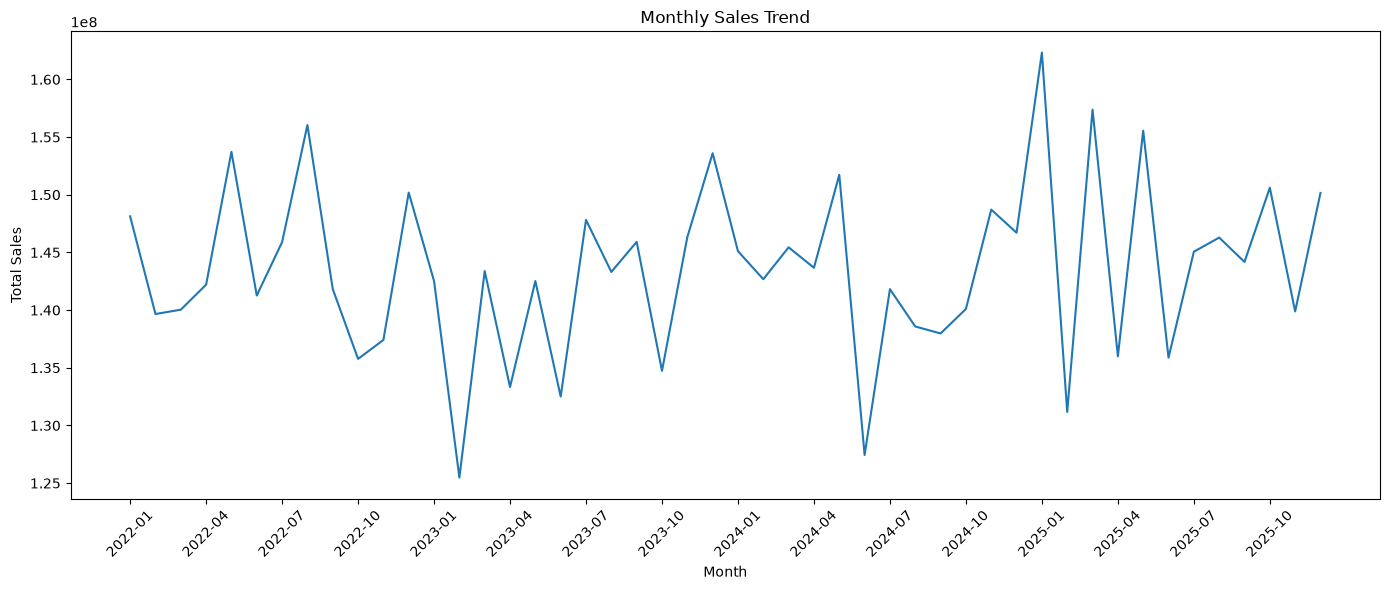

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Total_Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(
    range(0, len(monthly_analysis), 3),
    monthly_analysis["Year_Month"].iloc[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

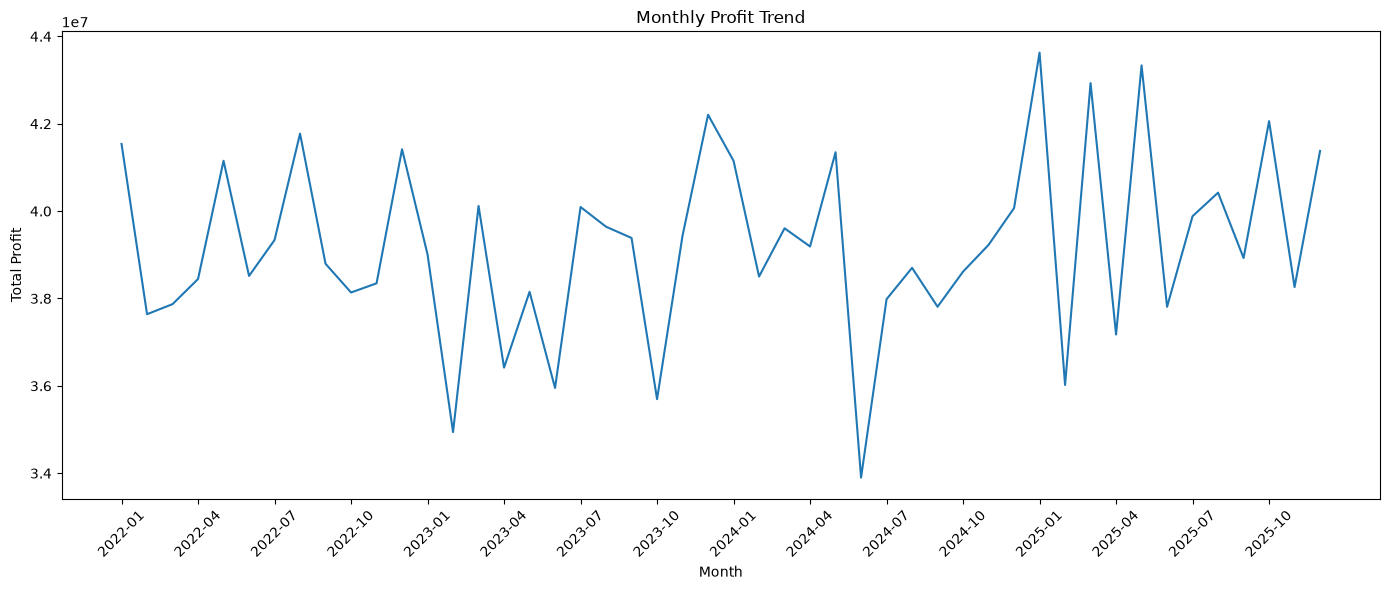

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Total_Profit"]
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(
    range(0, len(monthly_analysis), 3),
    monthly_analysis["Year_Month"].iloc[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

In [35]:
top_products = (
    order_details
    .merge(
        products[["Product_ID", "Product_Name", "Category"]],
        on="Product_ID",
        how="left"
    )
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_products

,Product_ID,Product_Name,Category,Total_Sales,Total_Profit,Total_Quantity
274,PROD1274,Monitor,Electronics,3.466342e+07,9.068578e+06,458
463,PROD1463,File Folder,Office Supplies,3.400226e+07,8.304231e+06,403
436,PROD1436,Bookshelf,Furniture,3.092600e+07,8.342760e+06,444
407,PROD1407,Camera,Electronics,3.088152e+07,8.786210e+06,417
421,PROD1421,Cookware,Home & Kitchen,3.061322e+07,8.399602e+06,466
384,PROD1384,Watch,Fashion,3.036824e+07,8.251718e+06,445
423,PROD1423,Bookshelf,Furniture,2.997466e+07,7.092901e+06,446
340,PROD1340,Vacuum Cleaner,Home & Kitchen,2.971873e+07,8.287206e+06,402
386,PROD1386,Lamp,Home & Kitchen,2.927773e+07,8.218030e+06,405
297,PROD1297,Vacuum Cleaner,Home & Kitchen,2.881641e+07,7.994368e+06,421


In [36]:
top_products["Profit_Margin_%"] = (
    top_products["Total_Profit"]
    / top_products["Total_Sales"]
) * 100

top_products["Profit_Margin_%"] = (
    top_products["Profit_Margin_%"].round(2)
)

top_products

,Product_ID,Product_Name,Category,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
274,PROD1274,Monitor,Electronics,3.466342e+07,9.068578e+06,458,26.16
463,PROD1463,File Folder,Office Supplies,3.400226e+07,8.304231e+06,403,24.42
436,PROD1436,Bookshelf,Furniture,3.092600e+07,8.342760e+06,444,26.98
407,PROD1407,Camera,Electronics,3.088152e+07,8.786210e+06,417,28.45
421,PROD1421,Cookware,Home & Kitchen,3.061322e+07,8.399602e+06,466,27.44
384,PROD1384,Watch,Fashion,3.036824e+07,8.251718e+06,445,27.17
423,PROD1423,Bookshelf,Furniture,2.997466e+07,7.092901e+06,446,23.66
340,PROD1340,Vacuum Cleaner,Home & Kitchen,2.971873e+07,8.287206e+06,402,27.89
386,PROD1386,Lamp,Home & Kitchen,2.927773e+07,8.218030e+06,405,28.07
297,PROD1297,Vacuum Cleaner,Home & Kitchen,2.881641e+07,7.994368e+06,421,27.74


In [37]:
order_status_analysis = (
    orders
    .groupby("Order_Status", dropna=False)
    .agg(
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Orders", ascending=False)
)

order_status_analysis

,Order_Status,Total_Orders
1,Delivered,41978
4,Shipped,5958
3,Returned,4287
0,Cancelled,4175
2,Pending,3602


In [38]:
delivery_status_analysis = (
    shipping
    .groupby("Delivery_Status", dropna=False)
    .agg(
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Orders", ascending=False)
)

delivery_status_analysis

,Delivery_Status,Total_Orders
3,On Time,43229
0,Delayed,9594
2,In Transit,4695
1,Failed,2482


In [39]:
return_analysis = (
    shipping
    .groupby("Return_Flag")
    .agg(
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

return_analysis["Return_Status"] = return_analysis["Return_Flag"].map({
    0: "Not Returned",
    1: "Returned"
})

total_shipping_orders = return_analysis["Total_Orders"].sum()

return_analysis["Percentage"] = (
    return_analysis["Total_Orders"] / total_shipping_orders
) * 100

return_analysis["Percentage"] = return_analysis["Percentage"].round(2)

return_analysis

,Return_Flag,Total_Orders,Return_Status,Percentage
0,False,54031,NaN,90.05
1,True,5969,NaN,9.95


In [40]:
return_impact = (
    shipping[["Order_ID", "Return_Flag"]]
    .merge(
        order_details[["Order_ID", "Sales", "Profit"]],
        on="Order_ID",
        how="left"
    )
    .groupby("Return_Flag")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

return_impact["Return_Status"] = return_impact["Return_Flag"].map({
    False: "Not Returned",
    True: "Returned"
})

return_impact

,Return_Flag,Total_Sales,Total_Profit,Total_Orders,Return_Status
0,False,6.218293e+09,1.699990e+09,54031,Not Returned
1,True,6.774366e+08,1.840012e+08,5969,Returned


In [41]:
shipping_mode_analysis = (
    orders
    .groupby("Shipping_Mode", dropna=False)
    .agg(
        Total_Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

shipping_mode_analysis["Shipping_Mode"] = (
    shipping_mode_analysis["Shipping_Mode"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.title()
)

shipping_mode_analysis = (
    shipping_mode_analysis
    .sort_values("Total_Orders", ascending=False)
)

shipping_mode_analysis

,Shipping_Mode,Total_Orders
3,Standard,26526
1,Express,14621
0,Economy,8781
2,Same Day,7139
4,Unknown,2933


In [42]:
shipping_mode_analysis["Percentage"] = (
    shipping_mode_analysis["Total_Orders"]
    / shipping_mode_analysis["Total_Orders"].sum()
) * 100

shipping_mode_analysis["Percentage"] = (
    shipping_mode_analysis["Percentage"].round(2)
)

shipping_mode_analysis

,Shipping_Mode,Total_Orders,Percentage
3,Standard,26526,44.21
1,Express,14621,24.37
0,Economy,8781,14.64
2,Same Day,7139,11.90
4,Unknown,2933,4.89


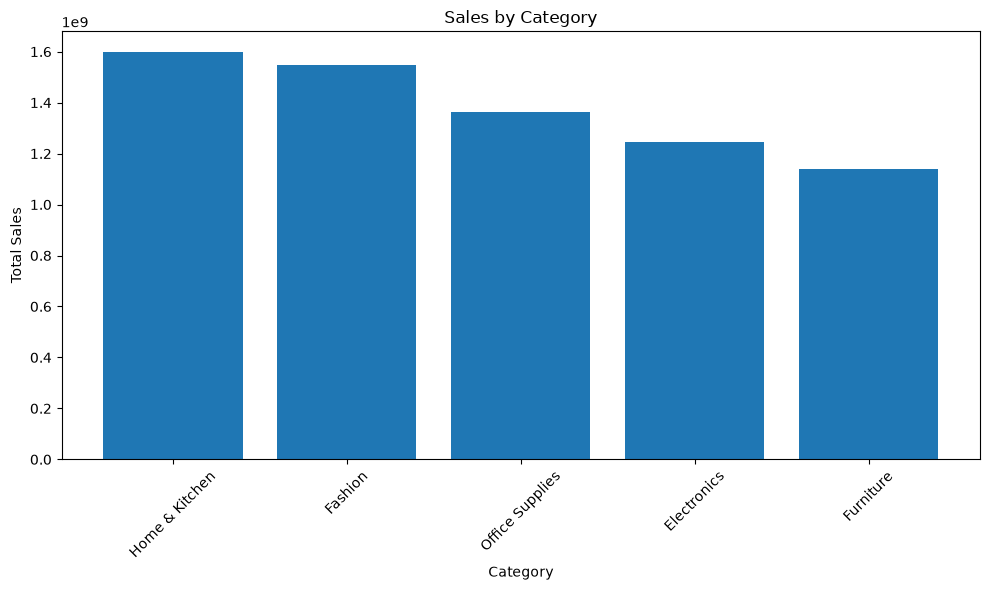

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis["Category"],
    category_analysis["Total_Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

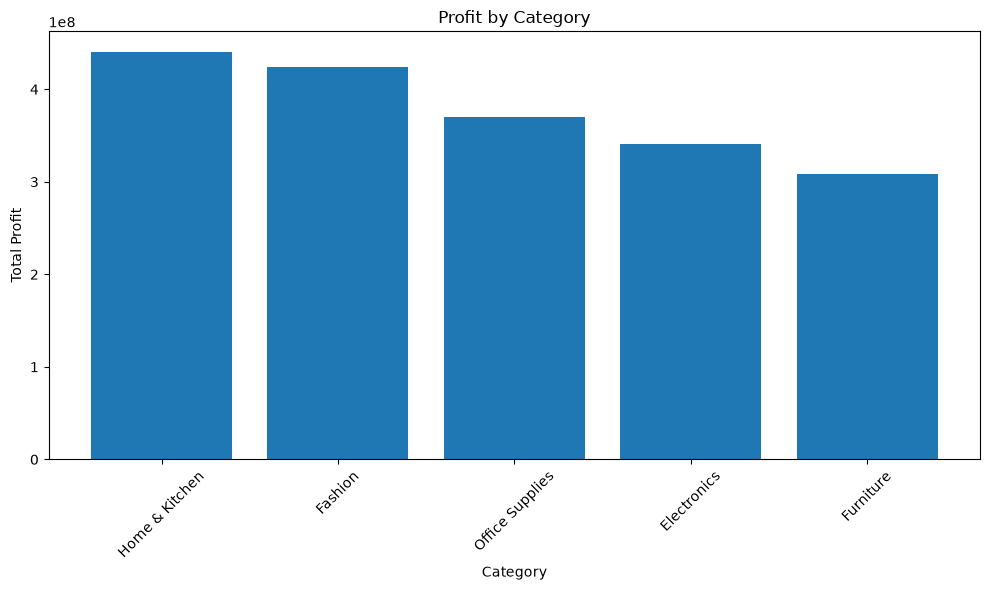

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis["Category"],
    category_analysis["Total_Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

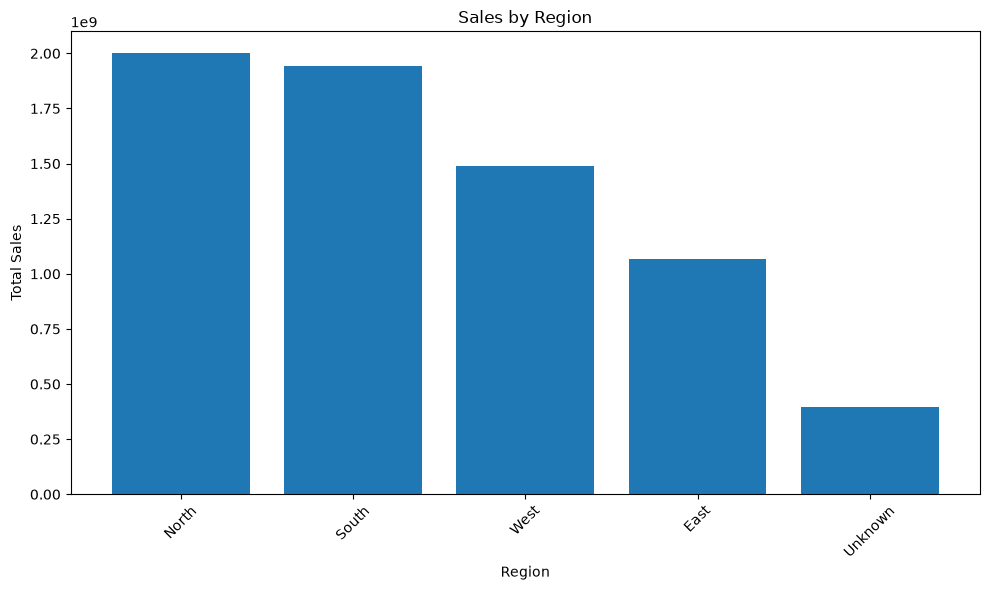

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    region_analysis["Region"],
    region_analysis["Total_Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

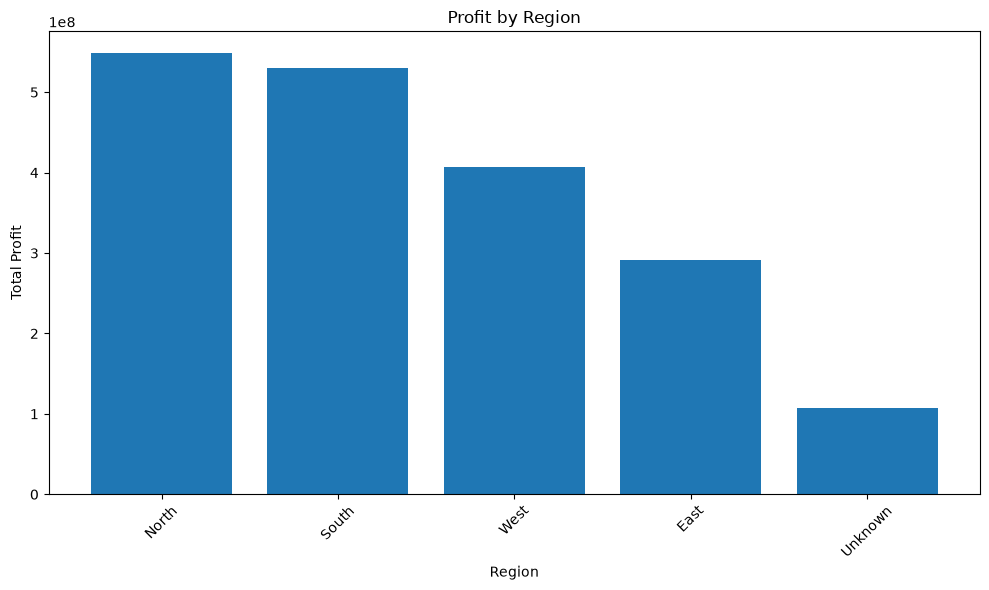

In [46]:
plt.figure(figsize=(10, 6))

plt.bar(
    region_analysis["Region"],
    region_analysis["Total_Profit"]
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

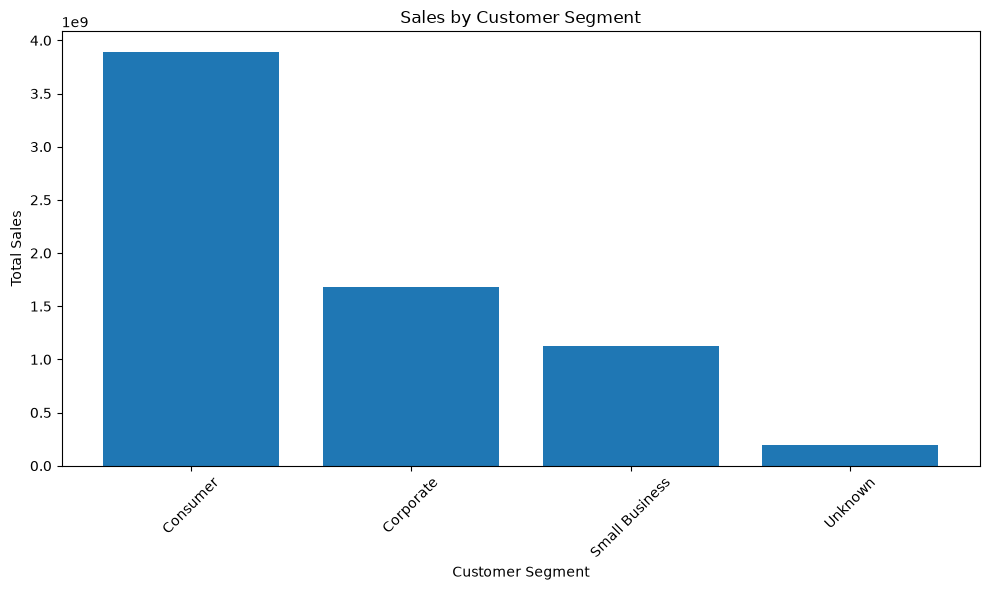

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["Customer_Segment"],
    segment_analysis["Total_Sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

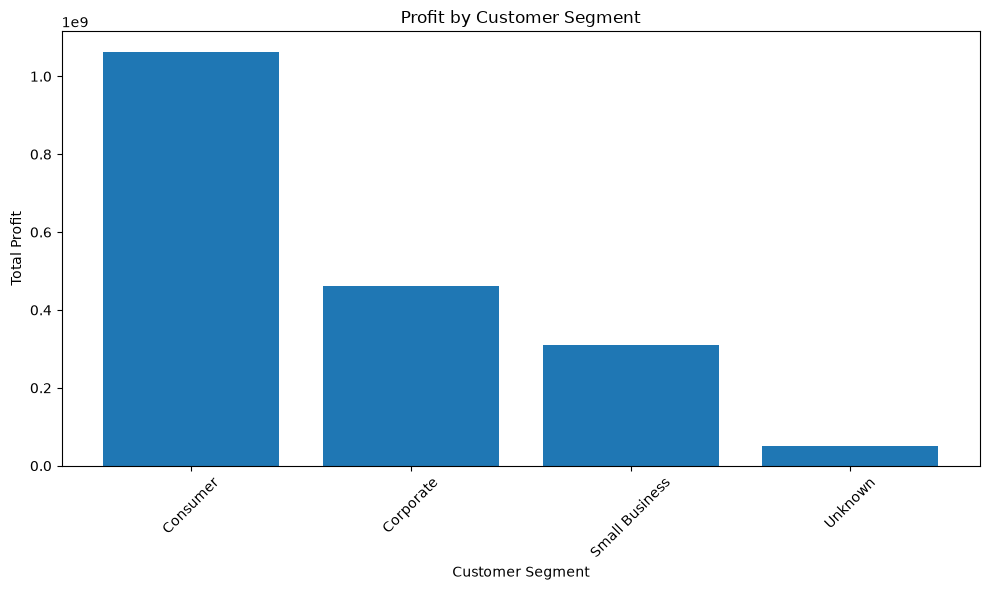

In [48]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["Customer_Segment"],
    segment_analysis["Total_Profit"]
)

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

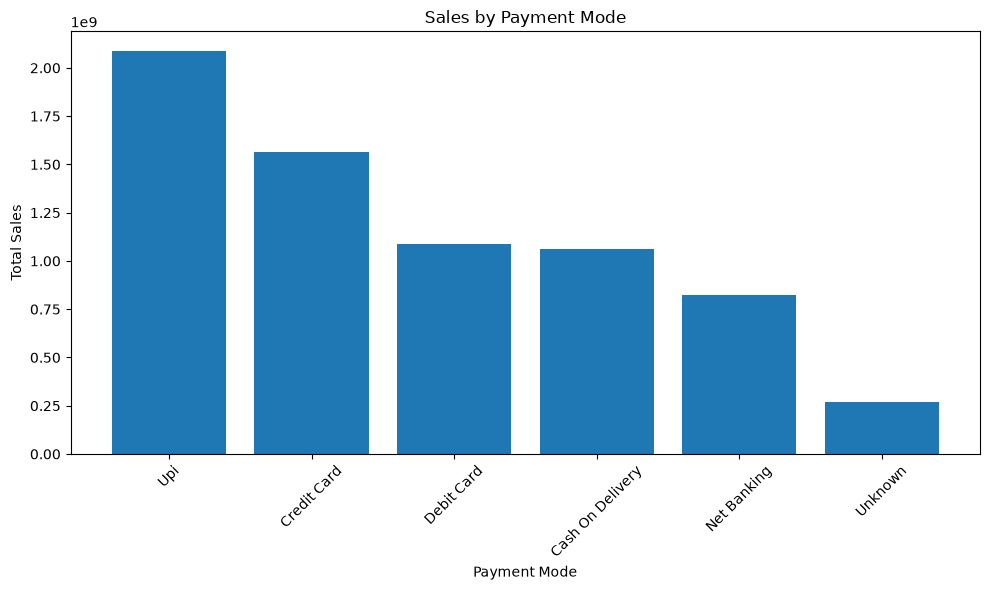

In [49]:
plt.figure(figsize=(10, 6))

plt.bar(
    payment_analysis["Payment_Mode"],
    payment_analysis["Total_Sales"]
)

plt.title("Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
print("===== CUSTOMERS DATA TYPES =====")
print(customers.dtypes)

print("\n===== ORDERS DATA TYPES =====")
print(orders.dtypes)

print("\n===== ORDER DETAILS DATA TYPES =====")
print(order_details.dtypes)

===== CUSTOMERS DATA TYPES =====
Customer_ID           str
Customer_Name         str
Age                 int64
Gender                str
City                  str
State                 str
Region                str
Customer_Segment      str
dtype: object

===== ORDERS DATA TYPES =====
Order_ID                    str
Customer_ID                 str
Order_Date       datetime64[us]
Shipping_Mode               str
Order_Status                str
dtype: object

===== ORDER DETAILS DATA TYPES =====
Order_ID            str
Product_ID          str
Quantity          int64
Discount        float64
Payment_Mode        str
Unit_Price      float64
Sales           float64
Cost            float64
Profit          float64
dtype: object


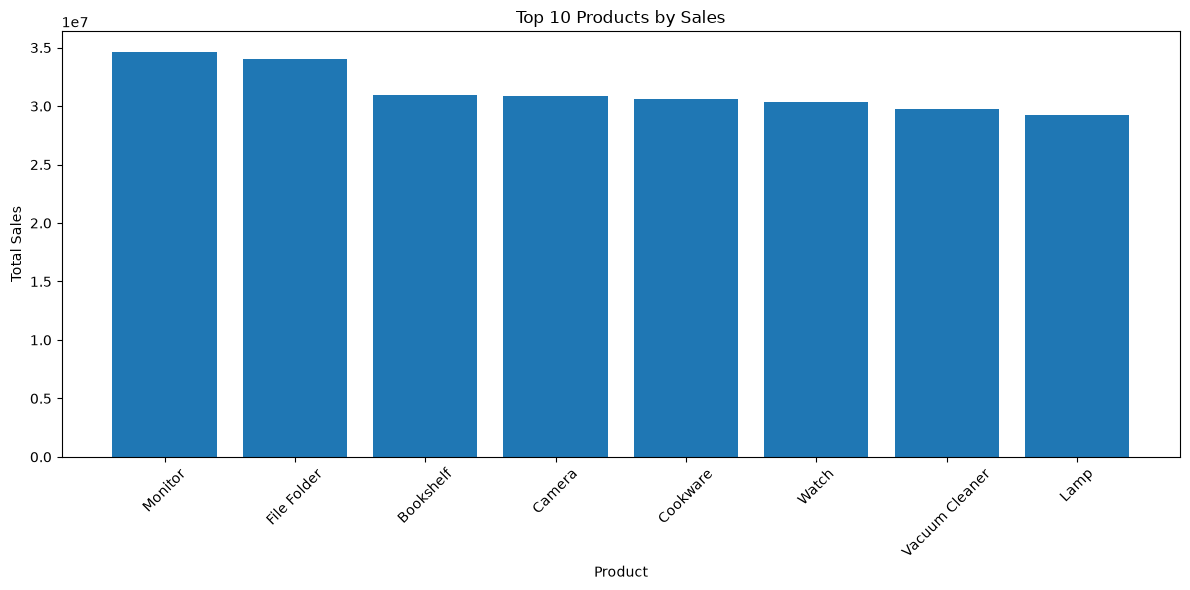

In [51]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_products["Product_Name"],
    top_products["Total_Sales"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

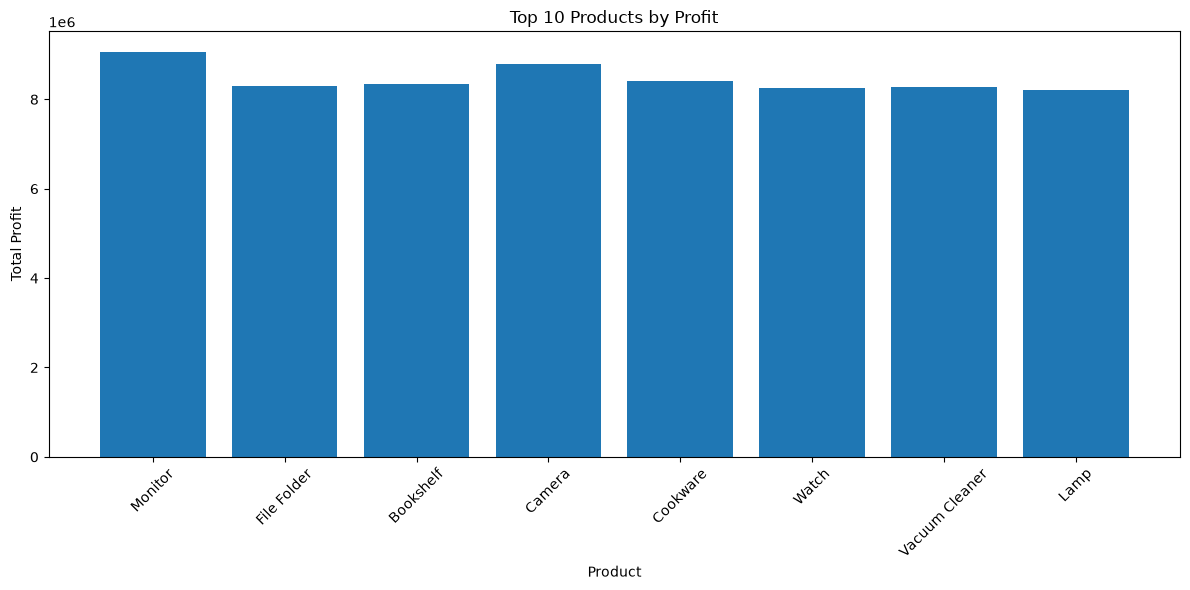

In [52]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_products["Product_Name"],
    top_products["Total_Profit"]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Product")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [53]:
print("===== CUSTOMERS DATA TYPES =====")
print(customers.dtypes)

print("\n===== ORDERS DATA TYPES =====")
print(orders.dtypes)

print("\n===== ORDER DETAILS DATA TYPES =====")
print(order_details.dtypes)

===== CUSTOMERS DATA TYPES =====
Customer_ID           str
Customer_Name         str
Age                 int64
Gender                str
City                  str
State                 str
Region                str
Customer_Segment      str
dtype: object

===== ORDERS DATA TYPES =====
Order_ID                    str
Customer_ID                 str
Order_Date       datetime64[us]
Shipping_Mode               str
Order_Status                str
dtype: object

===== ORDER DETAILS DATA TYPES =====
Order_ID            str
Product_ID          str
Quantity          int64
Discount        float64
Payment_Mode        str
Unit_Price      float64
Sales           float64
Cost            float64
Profit          float64
dtype: object


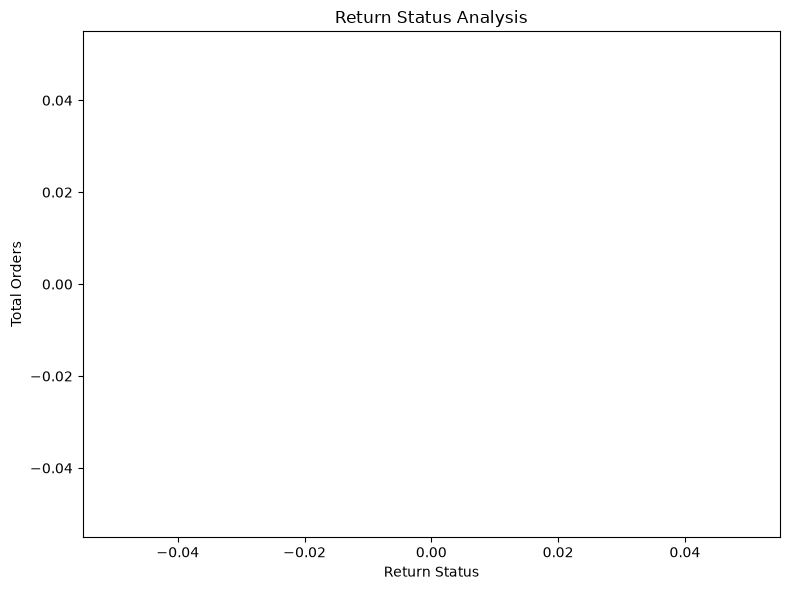

In [54]:
plt.figure(figsize=(8, 6))

plt.bar(
    return_analysis["Return_Status"],
    return_analysis["Total_Orders"]
)

plt.title("Return Status Analysis")
plt.xlabel("Return Status")
plt.ylabel("Total Orders")

plt.tight_layout()
plt.show()

In [55]:
print(delivery_status_analysis)
print(delivery_status_analysis.columns)

  Delivery_Status  Total_Orders
3         On Time         43229
0         Delayed          9594
2      In Transit          4695
1          Failed          2482
Index(['Delivery_Status', 'Total_Orders'], dtype='str')


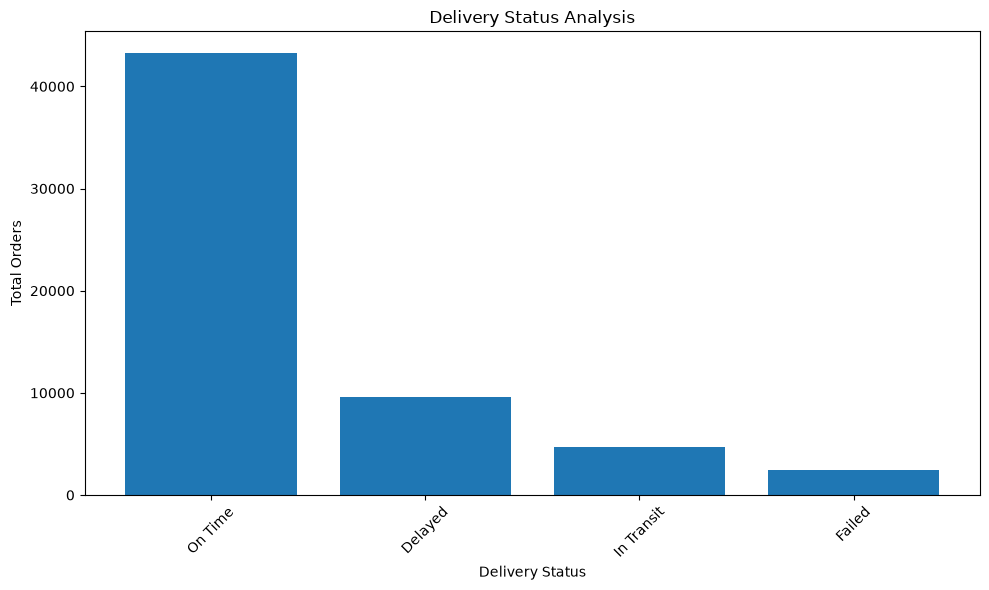

In [56]:
import matplotlib.pyplot as plt

delivery_status = delivery_status_analysis["Delivery_Status"].astype(str)
delivery_orders = delivery_status_analysis["Total_Orders"].astype(int)

plt.figure(figsize=(10, 6))

plt.bar(delivery_status, delivery_orders)

plt.title("Delivery Status Analysis")
plt.xlabel("Delivery Status")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

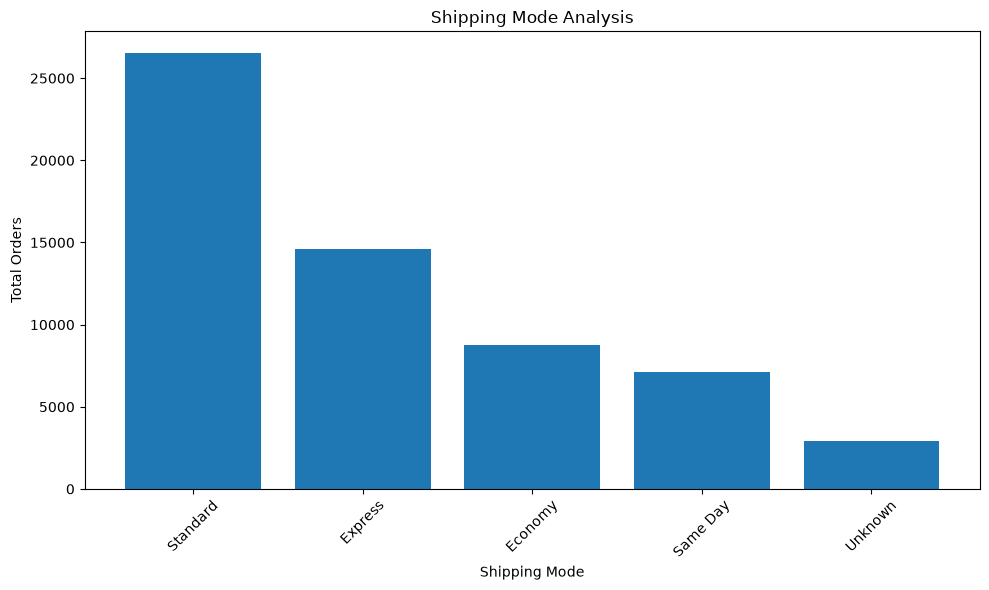

In [57]:
import matplotlib.pyplot as plt

shipping_modes = shipping_mode_analysis["Shipping_Mode"].astype(str)
shipping_orders = shipping_mode_analysis["Total_Orders"].astype(int)

plt.figure(figsize=(10, 6))

plt.bar(shipping_modes, shipping_orders)

plt.title("Shipping Mode Analysis")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

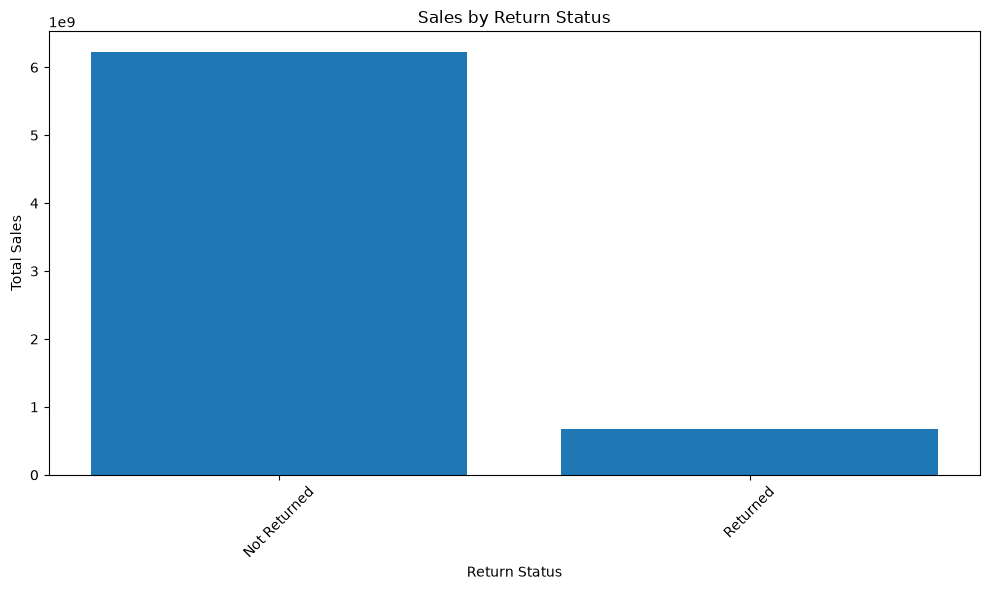

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    return_impact["Return_Status"],
    return_impact["Total_Sales"]
)

plt.title("Sales by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

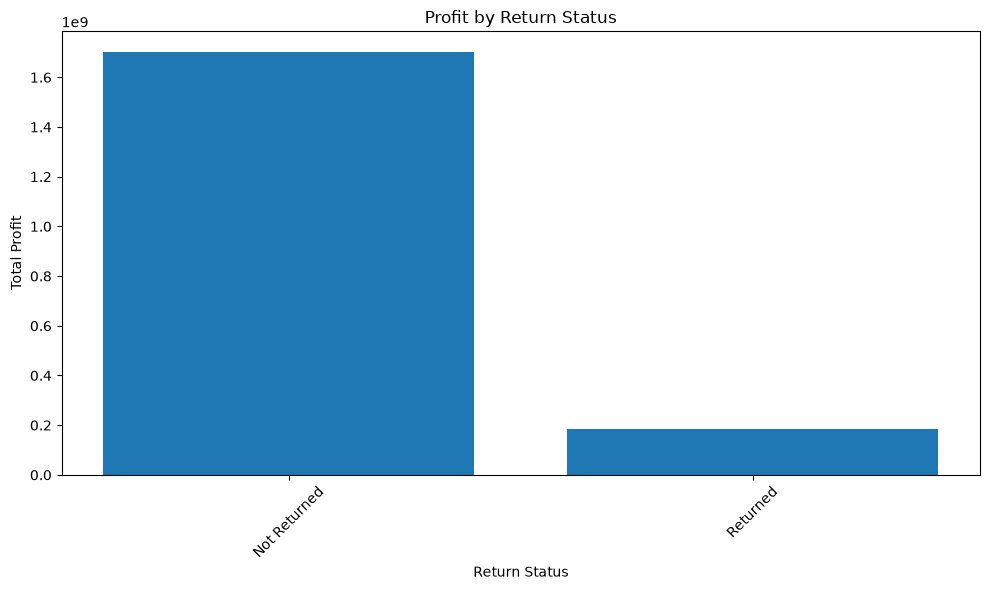

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    return_impact["Return_Status"],
    return_impact["Total_Profit"]
)

plt.title("Profit by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

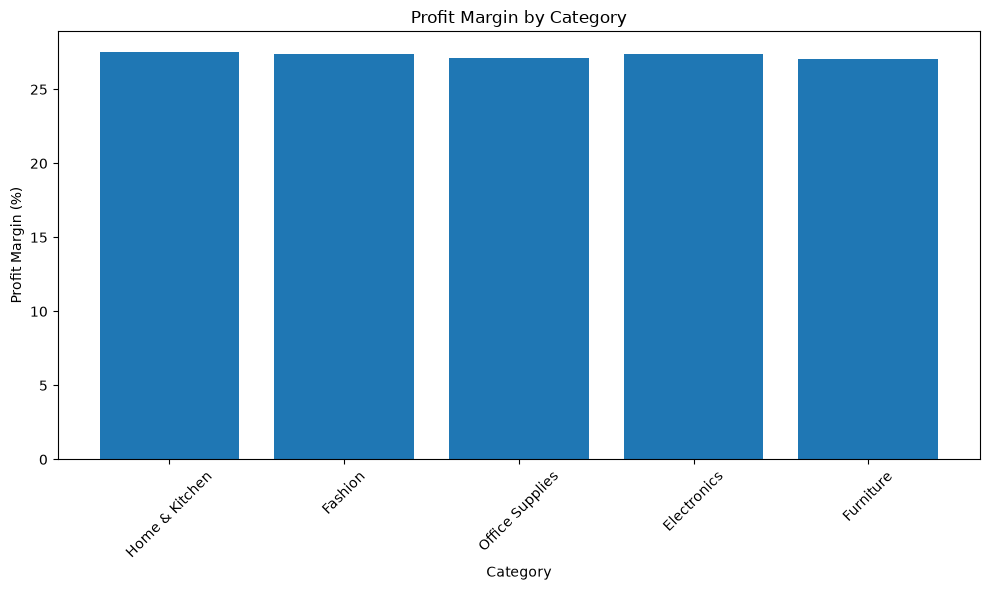

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    category_analysis["Category"],
    category_analysis["Profit_Margin_%"]
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
print(return_impact)
print(return_impact.columns)

   Return_Flag   Total_Sales  Total_Profit  Total_Orders Return_Status
0        False  6.218293e+09  1.699990e+09         54031  Not Returned
1         True  6.774366e+08  1.840012e+08          5969      Returned
Index(['Return_Flag', 'Total_Sales', 'Total_Profit', 'Total_Orders',
       'Return_Status'],
      dtype='str')


In [65]:
print(return_impact)

   Return_Flag   Total_Sales  Total_Profit  Total_Orders Return_Status
0        False  6.218293e+09  1.699990e+09         54031  Not Returned
1         True  6.774366e+08  1.840012e+08          5969      Returned


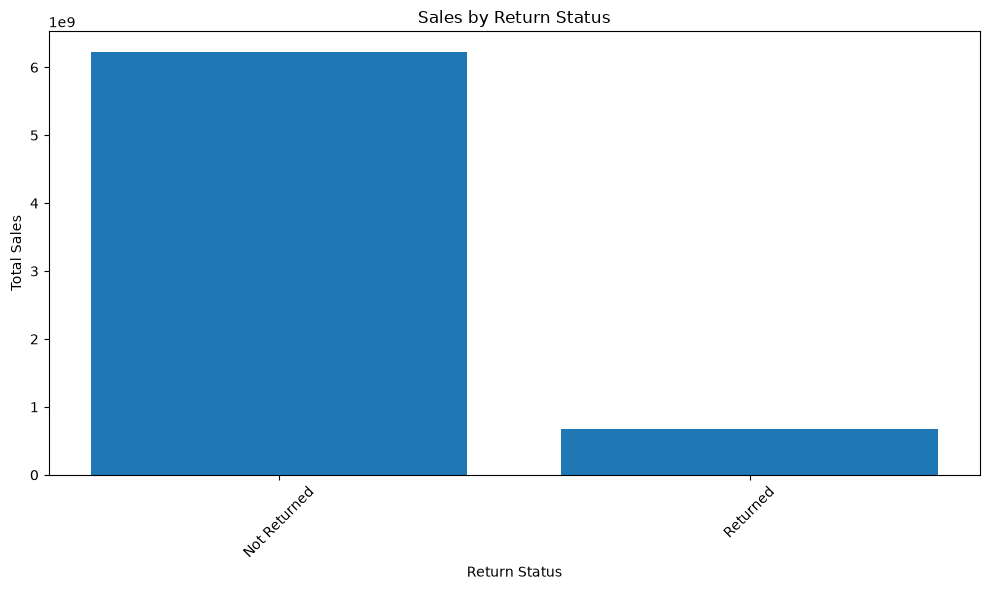

In [67]:
import matplotlib.pyplot as plt

return_status = return_impact["Return_Status"].astype(str)
return_sales = return_impact["Total_Sales"].astype(float)

plt.figure(figsize=(10, 6))

plt.bar(return_status, return_sales)

plt.title("Sales by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
print("===== CUSTOMERS DATA TYPES =====")
print(customers.dtypes)

print("\n===== ORDERS DATA TYPES =====")
print(orders.dtypes)

print("\n===== ORDER DETAILS DATA TYPES =====")
print(order_details.dtypes)

===== CUSTOMERS DATA TYPES =====
Customer_ID           str
Customer_Name         str
Age                 int64
Gender                str
City                  str
State                 str
Region                str
Customer_Segment      str
dtype: object

===== ORDERS DATA TYPES =====
Order_ID                    str
Customer_ID                 str
Order_Date       datetime64[us]
Shipping_Mode               str
Order_Status                str
dtype: object

===== ORDER DETAILS DATA TYPES =====
Order_ID            str
Product_ID          str
Quantity          int64
Discount        float64
Payment_Mode        str
Unit_Price      float64
Sales           float64
Cost            float64
Profit          float64
dtype: object


In [69]:
print("===== ECOMMERCE SALES ANALYSIS - BUSINESS INSIGHTS =====")

print("\n1. Overall Performance")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ₹{aov:,.2f}")

print("\n2. Category Performance")
print(category_analysis[[
    "Category",
    "Total_Sales",
    "Total_Profit",
    "Profit_Margin_%"
]].to_string(index=False))

print("\n3. Region Performance")
print(region_analysis[[
    "Region",
    "Total_Sales",
    "Total_Profit",
    "Profit_Margin_%"
]].to_string(index=False))

print("\n4. Customer Segment Performance")
print(segment_analysis[[
    "Customer_Segment",
    "Total_Sales",
    "Total_Profit",
    "Total_Orders",
    "Profit_Margin_%",
    "AOV"
]].to_string(index=False))

print("\n5. Return Analysis")
print(return_analysis.to_string(index=False))

print("\n6. Delivery Status")
print(delivery_status_analysis.to_string(index=False))

===== ECOMMERCE SALES ANALYSIS - BUSINESS INSIGHTS =====

1. Overall Performance
Total Sales: ₹6,895,729,728.44
Total Profit: ₹1,883,990,896.40
Total Orders: 60,000
Total Quantity Sold: 181,896
Profit Margin: 27.32%
Average Order Value: ₹114,928.83

2. Category Performance
       Category  Total_Sales  Total_Profit  Profit_Margin_%
 Home & Kitchen 1.599750e+09  4.405690e+08            27.54
        Fashion 1.546370e+09  4.238028e+08            27.41
Office Supplies 1.364820e+09  3.700177e+08            27.11
    Electronics 1.244381e+09  3.408384e+08            27.39
      Furniture 1.140410e+09  3.087630e+08            27.07

3. Region Performance
 Region  Total_Sales  Total_Profit  Profit_Margin_%
  North 2.000026e+09  5.482681e+08            27.41
  South 1.943268e+09  5.300823e+08            27.28
   West 1.486920e+09  4.070018e+08            27.37
   East 1.068367e+09  2.914878e+08            27.28
Unknown 3.971487e+08  1.071509e+08            26.98

4. Customer Segment Performanc

In [70]:
## Key Business Insights

1. The business generated total sales of approximately ₹6.90 billion with total profit of approximately ₹1.88 billion.

2. The overall profit margin was 27.32%, with an average order value of approximately ₹114,928.83.

3. Home & Kitchen generated the highest sales among all categories, followed by Fashion and Office Supplies.

4. North region recorded the highest sales and profit among the regions.

5. Consumer customers contributed the largest share of sales and profit among customer segments.

6. UPI was the most frequently used payment mode based on order count.

7. Standard shipping was the most commonly used shipping mode, accounting for 26,526 orders.

8. 43,229 orders were delivered on time, while 9,594 orders were delayed.

9. 5,969 orders were marked as returned, representing approximately 9.95% of shipping orders.

10. The monthly sales and profit trends show variations across the 2022–2025 period, providing useful information for identifying high-performing months and planning future sales activities.

SyntaxError: invalid character '₹' (U+20B9) (866969155.py, line 3)

In [71]:
## Key Business Insights

1. The business generated total sales of approximately ₹6.90 billion with total profit of approximately ₹1.88 billion.

2. The overall profit margin was 27.32%, with an average order value of approximately ₹114,928.83.

3. Home & Kitchen generated the highest sales among all categories, followed by Fashion and Office Supplies.

4. North region recorded the highest sales and profit among the regions.

5. Consumer customers contributed the largest share of sales and profit among customer segments.

6. UPI was the most frequently used payment mode based on order count.

7. Standard shipping was the most commonly used shipping mode, accounting for 26,526 orders.

8. 43,229 orders were delivered on time, while 9,594 orders were delayed.

9. 5,969 orders were marked as returned, representing approximately 9.95% of shipping orders.

10. The monthly sales and profit trends show variations across the 2022–2025 period, providing useful information for identifying high-performing months and planning future sales activities.

SyntaxError: invalid character '₹' (U+20B9) (866969155.py, line 3)

In [72]:
## Key Business Insights

In [73]:
1. The business generated total sales of approximately ₹6.90 billion with total profit of approximately ₹1.88 billion.

2. The overall profit margin was 27.32%, with an average order value of approximately ₹114,928.83.

3. Home & Kitchen generated the highest sales among all categories, followed by Fashion and Office Supplies.

4. North region recorded the highest sales and profit among the regions.

5. Consumer customers contributed the largest share of sales and profit among customer segments.

6. UPI was the most frequently used payment mode based on order count.

7. Standard shipping was the most commonly used shipping mode, accounting for 26,526 orders.

8. 43,229 orders were delivered on time, while 9,594 orders were delayed.

9. 5,969 orders were marked as returned, representing approximately 9.95% of shipping orders.

10. The monthly sales and profit trends show variations across the 2022–2025 period, providing useful information for identifying high-performing months and planning future sales activities.

SyntaxError: invalid character '₹' (U+20B9) (1769323321.py, line 1)

In [75]:
print("===== KEY BUSINESS INSIGHTS =====")

print("1. Total sales were approximately 6.90 billion.")
print("2. Total profit was approximately 1.88 billion.")
print("3. Overall profit margin was 27.32%.")
print("4. Average Order Value was approximately 114,928.83.")
print("5. Home & Kitchen generated the highest sales among categories.")
print("6. North region recorded the highest sales and profit.")
print("7. Consumer customers contributed the largest share of sales and profit.")
print("8. UPI was the most frequently used payment mode by order count.")
print("9. Standard shipping was the most commonly used shipping mode with 26,526 orders.")
print("10. 5,969 orders were returned, representing approximately 9.95% of shipping orders.")
print("11. 43,229 orders were delivered on time, while 9,594 were delayed.")
print("12. Monthly sales and profit varied across the 2022 to 2025 period.")

===== KEY BUSINESS INSIGHTS =====
1. Total sales were approximately 6.90 billion.
2. Total profit was approximately 1.88 billion.
3. Overall profit margin was 27.32%.
4. Average Order Value was approximately 114,928.83.
5. Home & Kitchen generated the highest sales among categories.
6. North region recorded the highest sales and profit.
7. Consumer customers contributed the largest share of sales and profit.
8. UPI was the most frequently used payment mode by order count.
9. Standard shipping was the most commonly used shipping mode with 26,526 orders.
10. 5,969 orders were returned, representing approximately 9.95% of shipping orders.
11. 43,229 orders were delivered on time, while 9,594 were delayed.
12. Monthly sales and profit varied across the 2022 to 2025 period.


In [76]:
print("===== PROJECT CONCLUSION =====")

print("This Ecommerce Sales Analysis project analyzed sales, profit, orders,")
print("customers, products, payment modes, regions, shipping and returns.")
print("The analysis was performed using Python with data retrieved from SQL Server.")
print("The project identified key business patterns across categories, regions,")
print("customer segments, products and time periods.")
print("The results can support business reporting, performance monitoring and")
print("data-driven decision making.")

===== PROJECT CONCLUSION =====
This Ecommerce Sales Analysis project analyzed sales, profit, orders,
customers, products, payment modes, regions, shipping and returns.
The analysis was performed using Python with data retrieved from SQL Server.
The project identified key business patterns across categories, regions,
customer segments, products and time periods.
The results can support business reporting, performance monitoring and
data-driven decision making.


In [9]:
print("""
==============================
ECOMMERCE SALES ANALYSIS
==============================

PROJECT OBJECTIVE

The objective of this project is to analyze ecommerce sales data using
Python, SQL Server, and Power BI.

The analysis focuses on sales, profit, orders, customers, products,
regions, customer segments, payment modes, shipping, and returns.

The goal is to identify important business patterns and generate
meaningful insights that can support business reporting and
data-driven decision making.
""")


ECOMMERCE SALES ANALYSIS

PROJECT OBJECTIVE

The objective of this project is to analyze ecommerce sales data using
Python, SQL Server, and Power BI.

The analysis focuses on sales, profit, orders, customers, products,
regions, customer segments, payment modes, shipping, and returns.

The goal is to identify important business patterns and generate
meaningful insights that can support business reporting and
data-driven decision making.



In [10]:
print("""
==============================
DATA SOURCES
==============================

The project uses ecommerce sales data stored in SQL Server.

The following five tables were used for analysis:

1. Customers
2. Products
3. Orders
4. Order_Details
5. Shipping

Data was loaded from SQL Server into Python using Pandas and SQLAlchemy.
The analysis was then performed using Pandas, NumPy, Matplotlib and Seaborn.
""")


DATA SOURCES

The project uses ecommerce sales data stored in SQL Server.

The following five tables were used for analysis:

1. Customers
2. Products
3. Orders
4. Order_Details
5. Shipping

Data was loaded from SQL Server into Python using Pandas and SQLAlchemy.
The analysis was then performed using Pandas, NumPy, Matplotlib and Seaborn.



In [11]:
print("""
==============================
DATA ANALYSIS METHODOLOGY
==============================

1. Connected Python to SQL Server.
2. Loaded the five ecommerce tables into Pandas DataFrames.
3. Checked data shape, columns and data types.
4. Checked missing values and data quality.
5. Standardized selected categorical values such as Region and Customer Segment.
6. Calculated key business KPIs including Sales, Profit, Orders, Quantity,
   Profit Margin and Average Order Value.
7. Performed category, region, customer segment and payment mode analysis.
8. Performed yearly and monthly sales and profit analysis.
9. Analyzed top-performing products.
10. Analyzed order status, delivery status, shipping mode and returns.
11. Created visualizations using Matplotlib and Seaborn.
12. Derived business insights from the analysis.
""")


DATA ANALYSIS METHODOLOGY

1. Connected Python to SQL Server.
2. Loaded the five ecommerce tables into Pandas DataFrames.
3. Checked data shape, columns and data types.
4. Checked missing values and data quality.
5. Standardized selected categorical values such as Region and Customer Segment.
6. Calculated key business KPIs including Sales, Profit, Orders, Quantity,
   Profit Margin and Average Order Value.
7. Performed category, region, customer segment and payment mode analysis.
8. Performed yearly and monthly sales and profit analysis.
9. Analyzed top-performing products.
10. Analyzed order status, delivery status, shipping mode and returns.
11. Created visualizations using Matplotlib and Seaborn.
12. Derived business insights from the analysis.



In [12]:
print("""
==============================
DATA QUALITY NOTES
==============================

The dataset was checked for missing values, duplicate records and
inconsistent categorical values.

Key observations:

1. Orders contained 80 missing Order_Date values.
2. Orders contained 2,933 missing Shipping_Mode values.
3. Order_Details contained 2,384 missing Payment_Mode values.
4. Order_Details contained 909 missing Sales values and 909 missing Profit values.
5. Products contained 7 missing Unit_Price values.
6. Region values with different capitalization were standardized in Python.
7. Customer Segment values with different capitalization were standardized in Python.
8. Missing values were retained where appropriate instead of being replaced
   with assumed values.
""")


DATA QUALITY NOTES

The dataset was checked for missing values, duplicate records and
inconsistent categorical values.

Key observations:

1. Orders contained 80 missing Order_Date values.
2. Orders contained 2,933 missing Shipping_Mode values.
3. Order_Details contained 2,384 missing Payment_Mode values.
4. Order_Details contained 909 missing Sales values and 909 missing Profit values.
5. Products contained 7 missing Unit_Price values.
6. Region values with different capitalization were standardized in Python.
7. Customer Segment values with different capitalization were standardized in Python.
8. Missing values were retained where appropriate instead of being replaced
   with assumed values.



In [13]:
print("""
==============================
KEY PERFORMANCE INDICATORS
==============================

Total Sales        : ₹6,895,729,728.44
Total Profit       : ₹1,883,990,896.40
Total Orders       : 60,000
Total Quantity     : 181,896
Total Customers    : 12,000
Profit Margin      : 27.32%
Average Order Value: ₹114,928.83
""")


KEY PERFORMANCE INDICATORS

Total Sales        : ₹6,895,729,728.44
Total Profit       : ₹1,883,990,896.40
Total Orders       : 60,000
Total Quantity     : 181,896
Total Customers    : 12,000
Profit Margin      : 27.32%
Average Order Value: ₹114,928.83

